# Master Pendulum: Basics

This notebook focuses on the *switching and synchronization logic* used by the
`MasterPendulum`, without instantiating the class itself. We reproduce the core
steps manually so the mechanics of mode switching are explicit and easy to verify.


## Overview

1. Import the FMU, OpenSim, and FEM pendulum components.
2. Verify that their port interfaces are compatible (name, type, direction, and unit).
3. Synchronize rigid-body parameters using the FEM model as reference.
4. Define a simple rigid-body reference trajectory for validation.
5. Check consistent initial conditions across models.
6. Define a time-based mode selector.
7. Define state adaptation for switching.
8. Run a short multi-model simulation with manual switching.
9. Record synchronization events and compare outputs against the reference.


## Learning Goals

- Understand the switching and synchronization workflow used in `MasterPendulum`.
- Verify port compatibility across heterogeneous models.
- Synchronize parameters so models represent the same physical pendulum.
- Implement a mode selector and state adaptation for switching.
- Validate switching behavior with a reference trajectory and event log.


## Prerequisites and Setup

Review the individual model tutorials before this notebook:
- `FMUPendulum` (Modelica / FMU)
- `OpenSimPendulum`
- `FEMPendulum`

For reference, the full implementation lives in:
- `demos/ControlledPendulum/src/master_pendulum/orchestration/master_pendulum.py`
- `syssimx/core/multi_comp.py`


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from syssimx import CoSimComponent
from syssimx.core.port import PortSpec

## Implementation


### Pendulum Model Import and Instantiation

We reuse the pendulum component implementations from the demo directory.


In [2]:
from demos.ControlledPendulum.src.master_pendulum.components import (
    FEMPendulum,
    FMUPendulum,
    OpenSimPendulum,
)

fmu     = FMUPendulum(name="FMUPendulum", solver="cvode")
opensim = OpenSimPendulum(name="OpenSimPendulum")
fem     = FEMPendulum(name="FEMPendulum")

### Verify Port Interfaces

All submodels must expose the same external interface so a multi-model wrapper
can switch between them without rewiring the system.


The input and output ports are the interfaces to other components in `syssimx`.
To use multiple models inside one wrapper, the port specs must be compatible:
- same port names
- same type and direction
- compatible units

We use the same compatibility logic as `MultiComponent._unify_ports`.


In [3]:
models: dict[str, CoSimComponent]
models = {"FMU": fmu, "OpenSim": opensim, "FEM": fem}

from syssimx.core.port import PortSpec

def check_port_compatibility(models, spec_attr, label):
    ref_name, ref_model = next(iter(models.items()))
    ref_specs = getattr(ref_model, spec_attr)
    all_ok = True

    for model_name, model in models.items():
        specs = getattr(model, spec_attr)
        missing = sorted(set(ref_specs) - set(specs))
        extra = sorted(set(specs) - set(ref_specs))
        if missing or extra:
            all_ok = False
            print(f"{label} ports mismatch: {model_name} vs {ref_name}")
            if missing:
                print(f"  Missing in {model_name}: {missing}")
            if extra:
                print(f"  Extra in {model_name}: {extra}")

        for port_name in sorted(set(ref_specs) & set(specs)):
            ref_spec = ref_specs[port_name]
            spec = specs[port_name]
            name_ok = (ref_spec.name == port_name == spec.name)
            dir_ok = (ref_spec.direction == spec.direction)
            type_ok = (ref_spec.type == spec.type)
            unit_ok = PortSpec.compatible(ref_spec, spec)
            if not (name_ok and dir_ok and type_ok and unit_ok):
                all_ok = False
                print(f"  Incompatible port '{port_name}':")
                print(f"    {ref_name}: {ref_spec}")
                print(f"    {model_name}: {spec}")

    if all_ok:
        print(f"All {label.lower()} ports are compatible across models.")
    else:
        raise ValueError("Port specifications are not compatible. See output above.")

check_port_compatibility(models, "input_specs", "Input")
check_port_compatibility(models, "output_specs", "Output")


All input ports are compatible across models.
All output ports are compatible across models.


### Parameter Synchronization

After port compatibility is verified, we align the physical parameters across models.
We use the FEM model as reference because it computes mass, inertia, and equivalent length
from geometry and material properties.


In [4]:
from demos.ControlledPendulum.src.master_pendulum.components.fem import pendulum_config as config

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = np.rad2deg(0.3) # Initial angle
init_params.angular_velocity = 1.0
q0 = np.deg2rad(init_params.angular_position_deg)
init_params.drive_torque = 0 # Nm

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3    # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 7800  # Density for the pendulum

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 2
sim_params.with_contact = False
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 1e10

anim_params = config.AnimationParameters()
anim_params.animate = True

fem_parameters = {
    'mat_params': mat_params,
    'contact_params': contact_params,
    'init_params': init_params,
    'sim_params': sim_params,
    'anim_params': anim_params,
}

fem.set_parameters(**fem_parameters)
fem.initialize(t0=0)

#### Extract parameters from the initialized `FEMPendulum`


In [5]:
theta0_deg = fem.init_params.angular_position_deg
omega0 = fem.init_params.angular_velocity
pendulum_mass = fem.mass
pendulum_length = fem._equivalent_length
pendulum_inertia = fem.inertia

print(f"Extracted parameters from FEM model:")
print(f"  theta0:  {theta0_deg:.2f} degrees")
print(f"  omega0:  {omega0:.4f} rad/s")
print(f"  Mass:    {pendulum_mass:.4f} kg")
print(f"  Length:  {pendulum_length:.4f} m")
print(f"  Inertia: {pendulum_inertia:.4f} kg*m^2")

Extracted parameters from FEM model:
  theta0:  17.19 degrees
  omega0:  1.0000 rad/s
  Mass:    10.8430 kg
  Length:  0.1817 m
  Inertia: 0.4423 kg*m^2


#### Synchronize `FMUPendulum` and `OpenSimPendulum`

The FMU and OpenSim models are updated to match the FEM-derived mass, length, and inertia.


In [6]:
opensim.parameters['InitialConditions']['theta_start'] = np.deg2rad(theta0_deg)
opensim.parameters['InitialConditions']['omega_start'] = omega0
opensim.parameters['Model']['mass'] = pendulum_mass
opensim.parameters['Model']['length'] = pendulum_length

head_inertia = pendulum_inertia - pendulum_mass * pendulum_length**2
opensim.parameters['Model']['inertia'] = head_inertia

opensim.initialize(t0=0)

fmu_parameters = fmu.get_parameters()
fmu_parameters['L'] = pendulum_length
fmu_parameters['m'] = pendulum_mass
fmu_parameters['J'] = pendulum_inertia
fmu_parameters['theta_start'] = np.deg2rad(theta0_deg)
fmu_parameters['omega_start'] = omega0
fmu.set_parameters(**fmu_parameters)

fmu.initialize(t0=0)


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


### Verify Consistent Initial Conditions

We check that all models start from the same angle and angular velocity.


In [7]:
for model in models.values():
    outputs = model.get_outputs()
    print(model.name)
    keys = list(sorted(outputs.keys()))
    for key in keys:
        print(f"  {key:>5}: {outputs[key]} ")

FMUPendulum
  alpha: -12.910878069650867 rad/s² 
  omega: 1.0 rad/s 
  theta: 0.3 rad 
OpenSimPendulum
  alpha: -12.910878069650867 rad/s² 
  omega: 1.0 rad/s 
  theta: 0.3 rad 
FEMPendulum
  alpha: -12.910878069650858 rad/s² 
  omega: 1.0000000000000002 rad/s 
  theta: 0.29999999999999966 rad 


### Setup Reference Implementation

We integrate a rigid-body pendulum ODE using `scipy.integrate.solve_ivp`.
This provides a baseline trajectory for sanity checking the multi-model outputs.


In [8]:
m = pendulum_mass
g = 9.81
L = pendulum_length
I = pendulum_inertia

def pendulum_dynamics(y: np.ndarray):
    theta, omega = y
    alpha = -(m * g * L * np.sin(theta)) / I
    return np.array([omega, alpha])

y0 = np.array([np.deg2rad(theta0_deg), omega0])

t_end = sim_params.t_end
dt_ref = 1e-3

sol = solve_ivp(
    fun=lambda t, y: pendulum_dynamics(y),
    t_span=[0, t_end],
    y0=y0,
    method='RK45',
    t_eval=np.arange(0, t_end+0.001, 0.001)
)

t_ref = sol.t
theta_ref, omega_ref = sol.y
alpha_ref = -(m * g * L * np.sin(theta_ref)) / I

At this point, parameters and initial conditions are aligned across all models.
This is the minimum requirement for a meaningful switch.


We build a small dictionary to switch between models by name and choose the initial mode.


### Time-Based Mode Selector

A simple selector that cycles through models over fixed time intervals.
This is useful for validation and debugging.


In [9]:
def time_based_mode_selector(t, t_end):
    interval = t_end / 12
    cycle_position = int(t / interval) % 3
    if cycle_position == 0:
        return 'FMU'
    elif cycle_position == 1:
        return 'OpenSim'
    else:
        return 'FEM'

### State Adaptation

Switching requires translating the state between model conventions.
We map the shared rigid-body state (`q`, `omega`, `torque`) to the target model.
For the FMU, state changes are applied by resetting initial conditions.

**Limitations:**
- FMU switching resets the solver state (internal history is lost).
- Switching from FEM to rigid-body is a projection: deformation states are not retained.
  This is best demonstrated with a stiff pendulum where elastic effects are small.


In [10]:
def _value(entry):
    if isinstance(entry, dict) and "value" in entry:
        return entry["value"]
    return entry

def adapt_state(active_state, new_mode):
    if new_mode == "FMU":
        return {
            "theta_start": active_state["theta"],
            "omega_start": active_state["omega"],
            "tau": active_state["tau"],
        }
    return active_state


### Mode Switching Logic

We combine the selector and state adaptation to perform controlled switches.


In [11]:
def switch_mode(active_model, active_mode, new_mode, t, sync_events):
    active_state = active_model.get_state()
    before = active_model.get_state()

    adapted_state = adapt_state(active_state, new_mode)
    new_model = models[new_mode]
    new_model.set_state(adapted_state, t)

    after = new_model.get_state()

    deltas = {}
    for key in ("theta", "omega", "tau"):
        b = _value(before.get(key))
        a = _value(after.get(key))
        if b is None or a is None:
            deltas[key] = None
        else:
            deltas[key] = a - b

    sync_events.append({
        "time": t,
        "from": active_mode,
        "to": new_mode,
        "before": before,
        "after": after,
        "delta": deltas,
    })

    return new_mode, new_model


### Time Stepping with Mode Switching

We step the active model, retrieve its state, adapt it, and continue with the next model.
This demonstrates the switching behavior end-to-end.


We start with zero torque to focus on state consistency across models.


In [12]:
active_mode = "FEM"
active_model = models[active_mode]

sync_events = []

# Simulation setup

t = 0.0
dt = 0.01
t_end = fem.sim_params.t_end

fem.setup_monitoring()
fem.display_monitoring()
fem.initialize_scene()


HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

![Pendulum Monitoring](pendulum_monitoring.png)

In [13]:
import time
def update_monitoring_and_animation(t):
    state = active_model.get_state()
    if active_mode != 'FEM':
        fem.update_scene(state['theta']['value'], t)
    fem.widgets['mode'].value = active_mode
    fem.widgets['time'].value = t
    fem.widgets['theta'].value = state['theta']['value']
    fem.widgets['omega'].value = state['omega']['value']
    fem.widgets['alpha'].value = state['alpha']['value']
    fem.widgets['tau'].value = state['tau']['value']
    fem.widgets['dt'].value = dt
    # delay for visualization purposes
    #time.sleep(0.01)

In [14]:
while t < t_end:
    new_mode = time_based_mode_selector(t, t_end)
    if new_mode != active_mode:
        active_mode, active_model = switch_mode(active_model, active_mode, new_mode, t, sync_events)
    active_model.do_step(t, dt)
    t += dt
    update_monitoring_and_animation(t)


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

### Synchronization Events

We list each switch along with the delta between the pre- and post-switch state
in the shared rigid-body coordinates. Small deltas indicate consistent synchronization.


In [21]:
import pandas as pd
from IPython.display import display

if not sync_events:
    print("No switches recorded.")
else:
    rows = []
    for ev in sync_events:
        rows.append({
            r"t in s": f"{ev['time']:.3f}",
            "From": ev["from"],
            "To": ev["to"],
            "Δθ": f"{ev['delta']['theta']:.4e}",
            "Δω": f"{ev['delta']['omega']:.4e}",
            "Δτ": f"{ev['delta']['tau']:.4e}",
        })
    df = pd.DataFrame(rows)
    df.index = range(1, len(df) + 1)
    df.index.name = "#"
    display(df.style.set_caption("Synchronization Events"))

,t in s,From,To,Δθ,Δω,Δτ
#,,,,,,
1,0.000,FEM,FMU,0.0000e+00,0.0000e+00,0.0000e+00
2,0.170,FMU,OpenSim,0.0000e+00,0.0000e+00,0.0000e+00
3,0.340,OpenSim,FEM,-4.1633e-17,1.7764e-15,0.0000e+00
4,0.500,FEM,FMU,0.0000e+00,0.0000e+00,0.0000e+00
5,0.670,FMU,OpenSim,0.0000e+00,0.0000e+00,0.0000e+00
6,0.840,OpenSim,FEM,-1.8041e-16,-8.8818e-16,0.0000e+00
7,1.000,FEM,FMU,0.0000e+00,0.0000e+00,0.0000e+00
8,1.170,FMU,OpenSim,0.0000e+00,0.0000e+00,0.0000e+00
9,1.340,OpenSim,FEM,-1.3878e-16,1.1102e-15,0.0000e+00


## Verification of Model Switching

We compare the multi-model output against the reference trajectory to confirm
that switching does not introduce large discontinuities in `q` and `omega`.


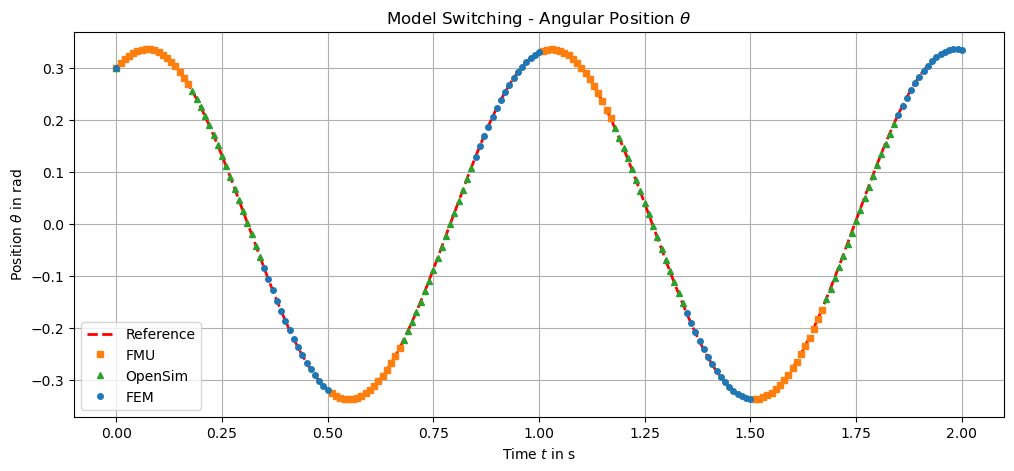

In [27]:
histories = {mode: models[mode].get_history() for mode in models.keys()}

common_style = {'linestyle': 'None', 'markersize': 4}
fem_style = {**common_style, 'marker': 'o', 'color': 'tab:blue', 'label': 'FEM'}
fmu_style = {**common_style, 'marker': 's', 'color': 'tab:orange', 'label': 'FMU'}
opensim_style = {**common_style, 'marker': '^', 'color': 'tab:green', 'label': 'OpenSim'}
ref_style = {'linestyle': '--', 'color': 'red', 'label': 'Reference', 'linewidth': 2}

styles = {'FEM': fem_style, 'FMU': fmu_style, 'OpenSim': opensim_style}

plt.figure(figsize=(12, 5))
plt.title("Model Switching - Angular Position $\\theta$")
plt.plot(t_ref, theta_ref, **ref_style)
for mode, history in histories.items():
    plt.plot(history['theta']['time'], history['theta']['values'], **styles[mode])
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Position $\theta$ in rad")
plt.grid()
plt.legend()
plt.show()

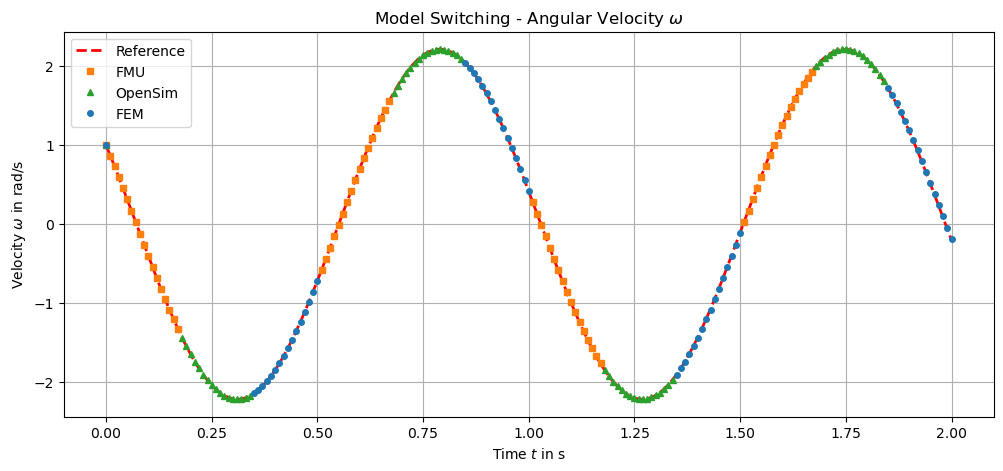

In [26]:
plt.figure(figsize=(12, 5))
plt.title("Model Switching - Angular Velocity $\\omega$")
plt.plot(t_ref, omega_ref, **ref_style)
for mode, history in histories.items():
    plt.plot(history['omega']['time'], history['omega']['values'], **styles[mode])
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Velocity $\omega$ in rad/s")
plt.grid()
plt.legend()
plt.show()

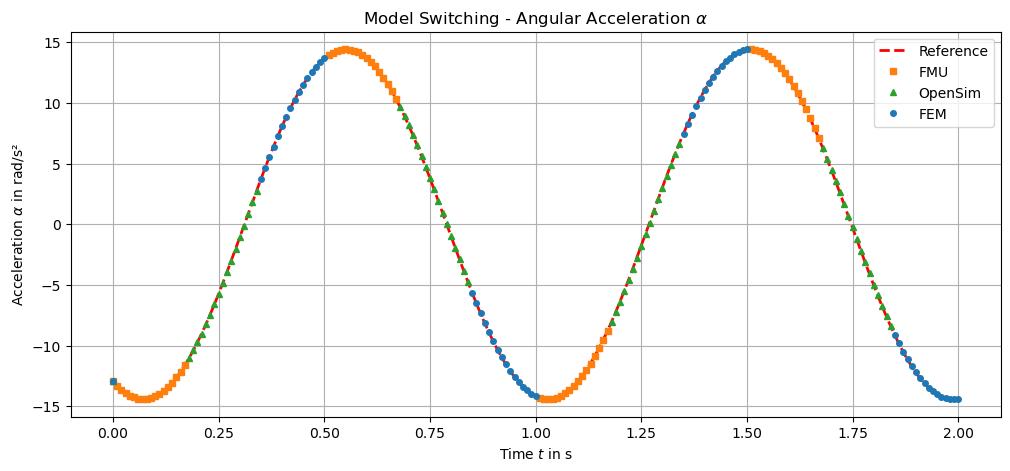

In [25]:
plt.figure(figsize=(12, 5))
plt.title("Model Switching - Angular Acceleration $\\alpha$")
plt.plot(t_ref, alpha_ref, **ref_style)

for mode, history in histories.items():
    plt.plot(history['alpha']['time'], history['alpha']['values'], **styles[mode])
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Acceleration $\alpha$ in rad/s²")
plt.grid()
plt.legend()
plt.show()

## Conclusion

You now have a minimal, validated workflow for reproducing the `MasterPendulum`
switching logic without using the class directly.

Next: {doc}`02_master_pendulum_switching` uses the actual `MasterPendulum` wrapper in a hybrid `System`.
